### Objective 
***This project comprises the dataset from the Google Play Store, which contains information about various apps, including their ratings, reviews, sizes, and more. We need to analyze this data to gain insights that can help improve businesses' app development strategies, enhance user experience, and increase app downloads and revenues.***

### Problem Statement:
***The task is to analyze this dataset to uncover patterns and trends that can guide the company's decision-making process. The analysis should focus on understanding what factors contribute to high app ratings, identifying the most popular app categories, and exploring the impact of app size and price on user reviews and installs.***


In [35]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Loading the dataset
a=pd.read_csv("/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv")
df=pd.DataFrame(a)


In [ ]:
# returns the top 5 records

df.head()

In [4]:
# returns the bottom 5 records

df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [5]:
# Dataset info like total rows & columns, datatypes, memory usage, non-null values, etc

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
# Returns count of rows and columns
df.shape

(10841, 13)

In [7]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [3]:
# For numerical columns
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [8]:
# For non-numerical columns
df.describe(include="object")

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


### *Data Cleaning and Preprocessing*

In [9]:
# Check for missing values

df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [10]:
# Handling missing value

df["Rating"]=df["Rating"].fillna("No Rating available")

In [11]:
df["Current Ver"]=df["Current Ver"].fillna("0")

In [12]:
df.dropna(subset=["Content Rating","Android Ver", "Type"], inplace=True)


In [13]:
df["Content Rating"]=df["Content Rating"].dropna()

In [14]:
# check for duplicated rows

df.duplicated().sum()

np.int64(483)

In [15]:
# Removing duplicate rows

df.drop_duplicates(inplace=True)

In [44]:
# check for data types

df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                      object
Installs                 float64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

In [304]:
# Converting data types of columns like 'Last Updated ', ' Installs ', ' Price'

df['Last Updated']=pd.to_datetime(df["Last Updated"],errors='coerce')

df['Installs']=pd.to_numeric(df['Installs'], errors='coerce')

df['Price']=pd.to_numeric(df['Price'], errors='coerce')

df["Rating"]=pd.to_numeric(df["Rating"], errors='coerce')

df["Reviews"]=pd.to_numeric(df["Reviews"], errors='coerce')


In [18]:
# Case Conversion

df["Category"]=df["Category"].str.capitalize()


In [4]:
df["Genres"]=df["Genres"].str.title().str.strip()

In [21]:
# Striping the extra spaces from the columns names

df.columns=df.columns.str.strip()

### ***Basic Level Questions***

1. What is the average rating of apps in the dataset?


In [22]:
avg_rating = df["Rating"].mean()
print(avg_rating)

4.187817772778402


2. How many unique categories of apps are there?

In [23]:
# Unique values in each column

df.nunique()

App               9656
Category            33
Rating              39
Reviews           6001
Size               461
Installs             0
Type                 2
Price                1
Content Rating       6
Genres             119
Last Updated      1377
Current Ver       2832
Android Ver         33
dtype: int64

In [24]:
# Sum of all unique values in dataset

df["Category"].nunique()

33

3. What is the distribution of app sizes?

In [25]:
# Making sure SIZE Column is numeric such that we could use Histograms

df["Size"].dtype



dtype('O')

In [39]:
df["Size"]=pd.to_numeric(df["Size"], errors='coerce')

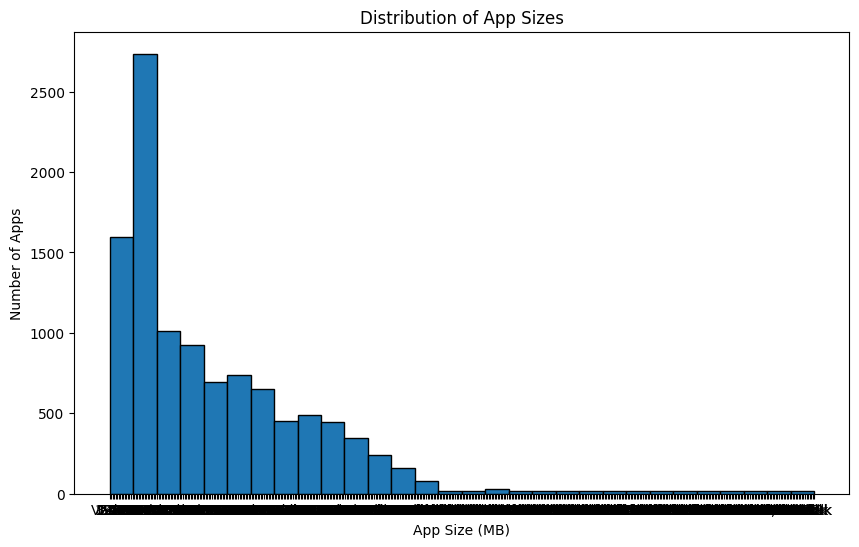

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['Size'], bins=30, edgecolor="black")

plt.title("Distribution of App Sizes")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Apps")
plt.show()

4. How many free vs paid apps are there?


In [ ]:
df["Type"].value_counts()

5. What is the most common content rating for apps?


In [ ]:
df["Rating"].mode()

6. What are the top 5 most installed apps?

In [ ]:
mask=df.sort_values(by='Installs',ascending=False)


In [ ]:
mask[["App","Installs"]].head()

7. How many apps have a rating of 4.0 and above?

In [ ]:
a=(df['Rating']>=4.0).value_counts()
a.iloc[0]

8.What is the average number of reviews for free vs paid apps?


In [53]:
df.groupby("Type")["Reviews"].mean().round(2)

Type
0             NaN
Free    478661.10
Paid     11673.31
Name: Reviews, dtype: float64

9. What is the average app size for each category?


In [58]:
df["Size"].dtype

dtype('O')

In [66]:
# cleaning the size column

df['Size']=df['Size'].str.replace("k","", regex=False)

df['Size']=df['Size'].str.replace("M","", regex=False)

df['Size']=pd.to_numeric(df['Size'],errors='coerce')

In [67]:
df.groupby("Category")["Size"].mean().round(2)

Category
1.9                       NaN
ART_AND_DESIGN          12.37
AUTO_AND_VEHICLES       34.50
BEAUTY                  13.80
BOOKS_AND_REFERENCE     40.35
BUSINESS                26.62
COMICS                  34.11
COMMUNICATION           55.79
DATING                  16.71
EDUCATION               30.53
ENTERTAINMENT           21.85
EVENTS                  19.82
FAMILY                  38.01
FINANCE                 28.89
FOOD_AND_DRINK          22.18
GAME                    45.80
HEALTH_AND_FITNESS      38.18
HOUSE_AND_HOME          25.62
LIBRARIES_AND_DEMO     180.83
LIFESTYLE               31.27
MAPS_AND_NAVIGATION     31.31
MEDICAL                 44.50
NEWS_AND_MAGAZINES      14.45
PARENTING               22.51
PERSONALIZATION         42.66
PHOTOGRAPHY             21.25
PRODUCTIVITY            35.63
SHOPPING                31.89
SOCIAL                  26.21
SPORTS                  32.48
TOOLS                   47.78
TRAVEL_AND_LOCAL        26.02
VIDEO_PLAYERS           22.03
W

10. How many apps were last updated in 2018?


In [81]:
df['Year']=df['Last Updated'].dt.year

In [85]:
# Count of Apps updated in 2018
(df['Year']==2018).sum()

np.int64(7349)

In [88]:
# To see those Apps

mask=df['Year']==2018

df[mask][["App","Last Updated"]].head(10)     # double square brackets returns multiple columns (a Dataframe) and single returns one column(a series)

,App,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018-01-07
1,Coloring book moana,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018-08-01
3,Sketch - Draw & Paint,2018-06-08
4,Pixel Draw - Number Art Coloring Book,2018-06-20
6,Smoke Effect Photo Maker - Smoke Editor,2018-04-26
7,Infinite Painter,2018-06-14
9,Kids Paint Free - Drawing Fun,2018-07-03
11,Name Art Photo Editor - Focus n Filters,2018-07-31
12,Tattoo Name On My Photo Editor,2018-04-02


### ***Medium-Level Questions:***

1. What is the correlation between the number of installs and the app rating?

In [98]:
# Both columns must be numeric

df['Rating'].dtype

dtype('float64')

In [145]:
df['Installs']=df['Installs'].replace("+","", regex=False)
df['Installs']=pd.to_numeric(df['Installs'], errors='coerce')

In [110]:
# Using Pandas

correlation= df['Installs'].corr(df['Rating'])
print("Correlation : "  ,correlation)

# The Pearson correlation coefficient between Installs and Rating is -0.143846
# That indicates a weak negative correlation.
# Apps with higher installs may have low ratings.
# Thus number of installs does not strongly influence an app's ratings

Correlation :  -0.14384674829981106


2. Which app categories have the highest average rating?


In [115]:
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).round(2).head(10)


Category
1.9                    19.00
EVENTS                  4.44
EDUCATION               4.39
ART_AND_DESIGN          4.36
BOOKS_AND_REFERENCE     4.35
PERSONALIZATION         4.34
PARENTING               4.30
GAME                    4.29
BEAUTY                  4.28
HEALTH_AND_FITNESS      4.28
Name: Rating, dtype: float64

3. How does the price of an app affect its average rating?


In [122]:
df['Price']=df['Price'].str.replace("$","", regex=False)
df['Price']=pd.to_numeric(df['Price'], errors='coerce')

In [125]:
df['Price'].dtype
df['Rating'].dtype

dtype('float64')

In [127]:
price_rating=df.groupby("Price")["Rating"].mean().round(2).reset_index()
print(price_rating)


# The higher the price, the lower the average rating

     Price  Rating
0     0.00    4.19
1     0.99    4.30
2     1.00    4.45
3     1.04     NaN
4     1.20    4.20
..     ...     ...
87  379.99    2.90
88  389.99    3.60
89  394.99     NaN
90  399.99    4.01
91  400.00    3.60

[92 rows x 2 columns]


4. What is the distribution of app ratings across different content ratings?

In [136]:
df["Rating"].dtype
df["Content Rating"].dtype

dtype('float64')

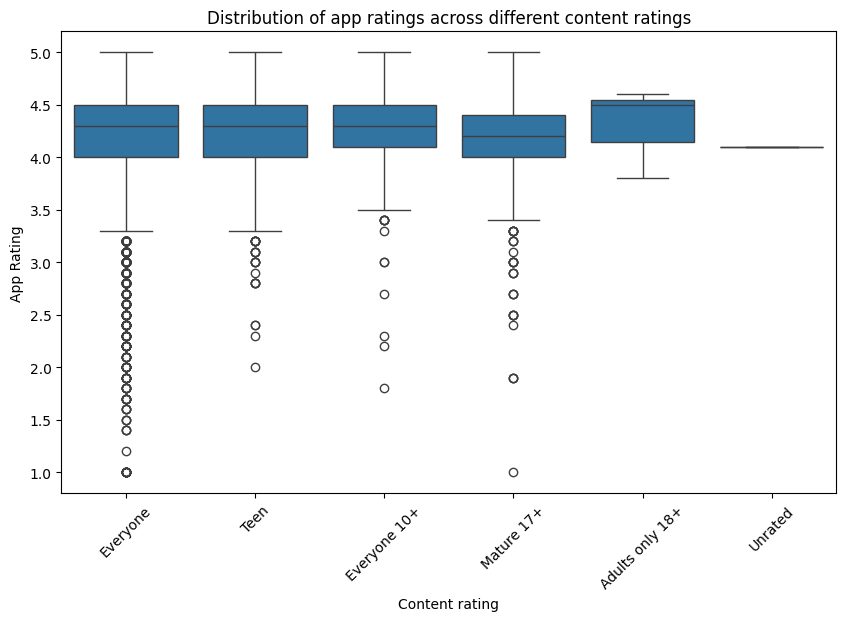

In [139]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Content Rating", y="Rating")
plt.title("Distribution of app ratings across different content ratings")
plt.xlabel("Content rating")
plt.ylabel("App Rating")

plt.xticks(rotation=45)
plt.show()

5. Which genres have the most apps with over 1 million installs?


In [273]:
df["Installs"]=df["Installs"].str.replace("+","")
df["Installs"]=df["Installs"].str.replace(",","")



In [19]:
# Removing a corrupted row containing "Free" in Installs columns
df=df[df["Installs"]!="Free"]

In [20]:
df["Installs"]=pd.to_numeric(df["Installs"])

In [203]:
app=df[df["Installs"]>1000000]

In [206]:
app.groupby("Genres")["App"].count().sort_values(ascending=False)


# Action Genres

Genres
Action                       190
Tools                        187
Photography                  172
Communication                167
Productivity                 138
                            ... 
Parenting                      1
Role Playing;Brain Games       1
Parenting;Music & Video        1
Sports;Action & Adventure      1
Tools;Education                1
Name: App, Length: 88, dtype: int64

6. How frequently do apps get updated? Calculate the average time between updates.

In [229]:
df["Last Updated"]=pd.to_datetime(df["Last Updated"])

In [234]:
latest=df["Last Updated"].max()        # Latest/ recent update date

In [235]:
df["Days_since_update"]=(latest-df["Last Updated"]).dt.days             # Pandas allows subtracting a list or an entire column from a single value
                                                                        # It automatically subtract every row in the Last updated column from latest date

In [236]:
avg_days=df["Days_since_update"].mean().round(2)
print(avg_days)

259.72


7. What is the impact of app size on the number of installs?


In [262]:
df["Size"].dtype

dtype('O')

In [289]:
df["Size"]=df["Size"].replace("M","")


In [291]:
df['Size']=pd.to_numeric(df['Size'],errors='coerce')

In [ ]:
df=df[df["Installs"]!="Free"]

In [ ]:
df["Installs"]=df["Installs"].str.replace("+","")
df["Installs"]=df["Installs"].str.replace(",","")


In [283]:
df['Installs']=pd.to_numeric(df['Installs'])

In [284]:
df["Installs"].dtype

dtype('int64')

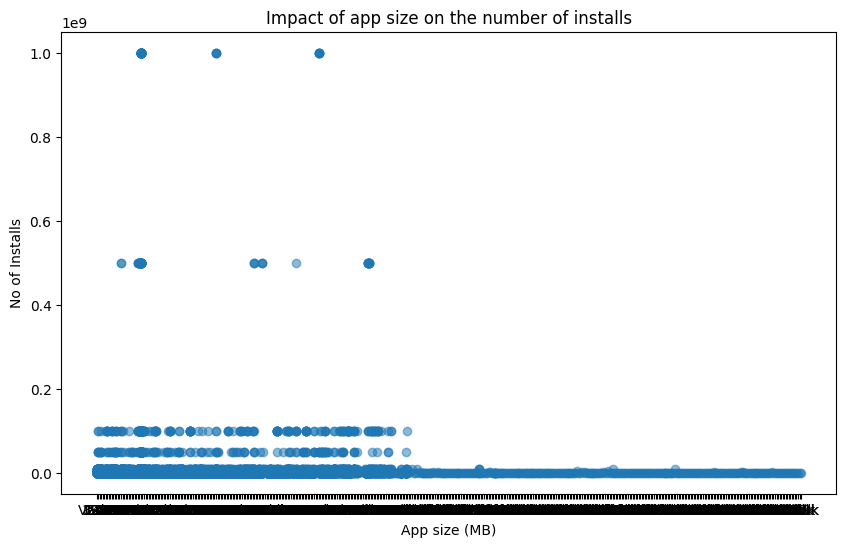

In [285]:
plt.figure(figsize=(10,6))
plt.scatter(df["Size"], df["Installs"], alpha=0.5)
plt.title("Impact of app size on the number of installs")
plt.xlabel("App size (MB)")
plt.ylabel("No of Installs")

plt.show()

In [292]:
# Advanced Analysis
# corr=df["Size"].corr(df["Installs"])
# print(corr)  

nan


8. Which apps have the highest number of reviews, and what are their ratings?

In [296]:
top_review=(df.sort_values(by="Reviews", ascending=False)[["App","Reviews","Rating"]])

top_review.head(10)

,App,Reviews,Rating
2989,GollerCepte Live Score,9992,4.2
4970,Ad Block REMOVER - NEED ROOT,999,3.3
2723,SnipSnap Coupon App,9975,4.2
2705,SnipSnap Coupon App,9975,4.2
3079,US Open Tennis Championships 2018,9971,4.0
3229,DreamTrips,9971,4.7
3049,US Open Tennis Championships 2018,9971,4.0
7002,Adult Color by Number Book - Paint Mandala Pages,997,4.3
6724,BSPlayer ARMv7 VFP CPU support,9966,4.3
7982,"Easy Resume Builder, Resume help, Curriculum v...",996,4.3


In [297]:
#a=df.groupby("App")["Reviews"].count().sort_values(ascending=False).reset_index()

9. How does the content rating distribution differ between free and paid apps?

In [298]:
content_type=pd.crosstab(df["Content Rating"],df["Type"])

content_type

Type,Free,Paid
Content Rating,,
Adults only 18+,3,0
Everyone,8019,695
Everyone 10+,380,33
Mature 17+,479,20
Teen,1156,52
Unrated,2,0


10. What are the top 5 categories with the most installs?

In [209]:
df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(5)

Category
GAME             35086024415
COMMUNICATION    32647276251
PRODUCTIVITY     14176091369
SOCIAL           14069867902
TOOLS            11452771915
Name: Installs, dtype: int64

### ***Advanced-Level Questions:***

1. What are the top 10 apps with the highest ratings, and how do their number of reviews and installs compare?

In [305]:
df["Rating"].dtype
df["Reviews"].dtype

dtype('int64')

In [310]:
df.sort_values(by="Rating", ascending=False) [["App","Rating","Reviews","Installs"]].reset_index().head(10)

,index,App,Rating,Reviews,Installs
0,10776,Monster Ride Pro,5.0,1,10
1,615,Awake Dating,5.0,2,100
2,612,American Girls Mobile Numbers,5.0,5,1000
3,654,Speeding Joyride & Car Meet App,5.0,3,100
4,10820,Fr. Daoud Lamei,5.0,22,1000
5,10529,FK CLASSIC FOR YOU,5.0,1,10
6,10416,FH School,5.0,4,100
7,10407,Jigsaw Volvo FH 16 Trucks,5.0,5,1000
8,10357,Ríos de Fe,5.0,141,1000
9,1547,Eternal life,5.0,26,1000


2. Analyze the trend of app updates over time. Are there any noticeable patterns or seasonal trends?

In [8]:
df['Last Updated']=pd.to_datetime(df['Last Updated'], errors='coerce')


In [11]:
df['Last Updated'].dtype

dtype('<M8[ns]')

In [9]:
df["Update_Year"]=df['Last Updated'].dt.year

In [10]:
# Count total records per year

update_trend=df.groupby("Update_Year").size().reset_index(name="Number_of_Updates")

print(update_trend)

   Update_Year  Number_of_Updates
0       2010.0                  1
1       2011.0                 15
2       2012.0                 26
3       2013.0                110
4       2014.0                209
5       2015.0                459
6       2016.0                804
7       2017.0               1867
8       2018.0               7349


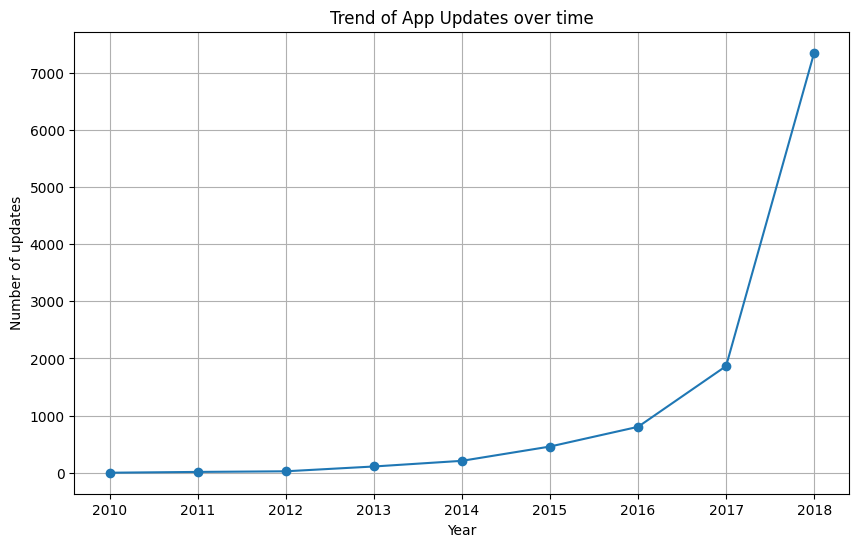

In [15]:
# Line trend is best for displaying trends over time

plt.figure(figsize=(10,6))
plt.plot(update_trend["Update_Year"],update_trend["Number_of_Updates"], marker='o')
plt.title("Trend of App Updates over time")
plt.xlabel("Year")
plt.ylabel("Number of updates")
plt.grid(True)
plt.show()

3. How does the average rating of apps change with the number of installs? Create a binned analysis

In [24]:
df['Installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [22]:
df['Installs'].dtype        # Should be integer

dtype('int64')

In [25]:
# Create Install Bins
my_bins = [0,1000,10000,100000,1000000,10000000,100000000,1000000000]

my_labels = [
    "0-1K",
    "1K-10K",
    "10K-100K",
    "100K-1M",
    "1M-10M",
    "10M-100M",
    "100M+"
]

df["Install_Bins"] = pd.cut(
    df["Installs"],
    bins=my_bins,
    labels=my_labels
)

In [26]:
df['Install_Bins']

0          1K-10K
1         100K-1M
2          1M-10M
3        10M-100M
4        10K-100K
           ...   
10836      1K-10K
10837        0-1K
10838        0-1K
10839        0-1K
10840      1M-10M
Name: Install_Bins, Length: 10840, dtype: category
Categories (7, object): ['0-1K' < '1K-10K' < '10K-100K' < '100K-1M' < '1M-10M' < '10M-100M' < '100M+']

In [30]:
# Calculate average rating

rating = (df.groupby("Install_Bins")["Rating"].mean().reset_index())

round(rating,2)

/tmp/ipykernel_58/2901585121.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating = (df.groupby("Install_Bins")["Rating"].mean().reset_index())


,Install_Bins,Rating
0,0-1K,4.20
1,1K-10K,4.04
2,10K-100K,4.09
3,100K-1M,4.21
4,1M-10M,4.29
5,10M-100M,4.39
6,100M+,4.31


4. Perform sentiment analysis on app reviews (if review text is available) to determine the common themes in high and low-rated apps.

In [33]:
df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver',
 'Update_Year',
 'Install_Bins']

The current Dataset contains a Reviews column that is (number of reviews), and does not contain review text.

***Without review text, no NLP or sentiment analysis can be performed. We need to load the dataset that contains sentiment column***

In [39]:
reviews = pd.read_csv("/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv")

merge_reviews = pd.merge(df, reviews, on="App",how="left")
merge_reviews.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN


In [40]:
merge_reviews["Sentiment"].value_counts()   # Positive reviews is higher, which means the users liked the Apps

Sentiment
Positive    46195
Negative    18134
Neutral      8286
Name: count, dtype: int64

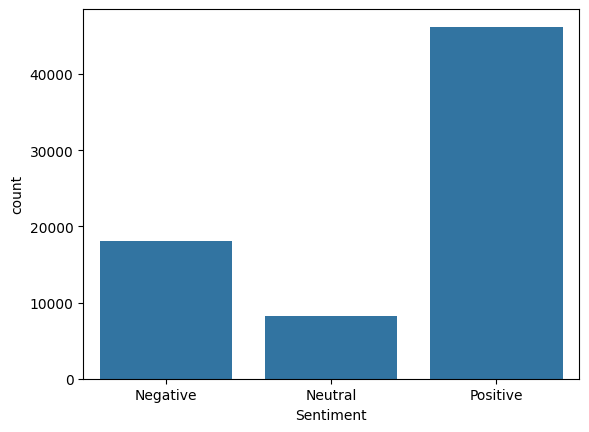

In [41]:
sns.countplot(
    data=merge_reviews,
    x="Sentiment"
)

plt.show()

5. What is the relationship between app genre and user ratings? Are certain genres consistently rated higher or lower?

In [47]:
data = (df.groupby("Genres")["Rating"].agg(["mean","median"]).sort_values(by='mean',ascending=False).reset_index()
)

data

,Genres,mean,median
0,"February 11, 2018",19.0,19.0
1,Board;Pretend Play,4.8,4.8
2,Comics;Creativity,4.8,4.8
3,Health & Fitness;Education,4.7,4.7
4,Puzzle;Education,4.6,4.6
...,...,...,...
115,Parenting;Brain Games,3.8,3.8
116,Art & Design;Action & Adventure,NaN,NaN
117,Books & Reference;Creativity,NaN,NaN
118,Role Playing;Education,NaN,NaN


### Conclusion

***This project performed Exploratory Data Analysis (EDA) on the Google Play Store dataset to understand the factors that influence an app's success, user satisfaction, and popularity. The dataset was first cleaned and preprocessed.
Using Pandas, NumPy, Matplotlib, and Seaborn, various analyses were performed to answer business questions related to app ratings, installs, categories, prices, genres, content ratings, and user engagement.***

***These insights can help app developers improve app quality, product managers prioritize high-performing categories, and marketing teams design better promotional strategies based on user behavior and market demand.***